In [1]:
#Install all the packages for data analysis and run regression models
!pip install pandas numpy openpyxl statsmodels linearmodels scipy matplotlib

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 376.2 kB/s eta 0:00:03
   ------------- -------------------------- 0.5/1.5 MB 376.2 kB/s eta 0:00:03
   ------------- -------------------------- 0.5/1.5 MB 376.2 kB/s eta 0:00:03
   -------------------- ------------------- 0.8/1.5 MB 388.6 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 388.6 kB/s e

In [3]:
#Load the libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels. panel import PanelOLS, RandomEffects
from scipy.stats import shapiro

In [5]:
df = pd.read_excel("C:/Users/ADMIN/Downloads/elly_data_workbook.xlsx", sheet_name="data_for_analysis")
df.head()

,Unnamed: 0,#,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 274,Unnamed: 275,Unnamed: 276,Unnamed: 277,Unnamed: 278,Unnamed: 279,Unnamed: 280,Unnamed: 281,Unnamed: 282,Unnamed: 283
0,NaN,NaN,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Bank Name,2014-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,2014-06-01 00:00:00,NaN,...,NaN,NaN,NaN,NaN,2025-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,...,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA
3,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
4,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992


In [6]:
#Load the Excel file to be analyzed
df = pd.read_excel(
    "C:/Users/ADMIN/Downloads/elly_data_workbook.xlsx", sheet_name="data_for_analysis",
    header=[0, 1, 2]
)

df.head()

Unnamed: 0_level_0                         #                      \
  Unnamed: 0_level_1        Unnamed: 1_level_1                2014   
  Unnamed: 0_level_2                 Bank Name 2014-03-01 00:00:00   
0                NaN                       NaN                 GDP   
1                1.0                  ABC Bank               0.052   
2                2.0  Bank Of Africa Kenya Ltd               0.052   
3                3.0            Bank of Baroda               0.052   
4                4.0             Bank of India               0.052   

                                                                     \
                                                                      
  2014-03-01 00:00:00.1 2014-03-01 00:00:00.2 2014-03-01 00:00:00.3   
0         Interest rate        Inflation rate         Asset Quality   
1                 16.91                0.0627              0.045406   
2                0.1691                0.0627              0.032328   
3                0.1691                0.0627              0.021059   
4                0.1691                0.0627               0.00851   

                                                                   \
                                                                    
  2014-03-01 00:00:00.4 2014-03-01 00:00:00.5 2014-06-01 00:00:00   
0        Mgt Efficiency                   ROA                 GDP   
1              0.695147              0.014665                0.06   
2              0.672879              0.012881                0.06   
3              0.256462              0.034448                0.06   
4              0.390441              0.020452                0.06   

                         ...                                              \
                         ...                  2025                         
  2014-06-01 00:00:00.1  ... 2025-09-01 00:00:00.2 2025-09-01 00:00:00.3   
0         Interest rate  ...        Inflation rate         Asset Quality   
1                0.1636  ...                0.0458              0.237645   
2                0.1636  ...                0.0458              0.125508   
3                0.1636  ...                0.0458              0.112626   
4                0.1636  ...                0.0458              0.108911   

                                                                   \
                                                                    
  2025-09-01 00:00:00.4 2025-09-01 00:00:00.5 2025-12-01 00:00:00   
0        Mgt Efficiency                   ROA                 GDP   
1              0.716459              0.001776                0.05   
2              0.796209              0.004696                0.05   
3              0.220336              0.026741                0.05   
4              0.117241              0.045793                0.05   

                                                                     \
                                                                      
  2025-12-01 00:00:00.1 2025-12-01 00:00:00.2 2025-12-01 00:00:00.3   
0         Interest rate        Inflation rate         Asset Quality   
1                0.1481                0.0449               0.39309   
2                0.1481                0.0449              0.130718   
3                0.1481                0.0449               0.10923   
4                0.1481                0.0449              0.109663   

                                               
                                               
  2025-12-01 00:00:00.4 2025-12-01 00:00:00.5  
0        Mgt Efficiency                   ROA  
1              0.725016             -0.015733  
2              0.749857              0.005992  
3              0.231151              0.031559  
4              0.118913              0.055792  

[5 rows x 284 columns]

In [7]:
df.columns

MultiIndex([('Unnamed: 0_level_0', 'Unnamed: 0_level_1', ...),
            (                 '#', 'Unnamed: 1_level_1', ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            (                 '#',                 2014, ...),
            ...
            (                 '#',                 2025, ...),
            (                 '#',                 2025, ...),
            (                 '#',                 2025, ...),
            (                 '#',                 2025, ...),
            (                 '#',                 2025, ...),
            (                 '#',     

In [8]:
df.columns = ['_'.join([str(i) for i in col]).strip() for col in df.columns]
df.head()

,Unnamed: 0_level_0_Unnamed: 0_level_1_Unnamed: 0_level_2,#_Unnamed: 1_level_1_Bank Name,#_2014_2014-03-01 00:00:00,#_2014_2014-03-01 00:00:00.1,#_2014_2014-03-01 00:00:00.2,#_2014_2014-03-01 00:00:00.3,#_2014_2014-03-01 00:00:00.4,#_2014_2014-03-01 00:00:00.5,#_2014_2014-06-01 00:00:00,#_2014_2014-06-01 00:00:00.1,...,#_2025_2025-09-01 00:00:00.2,#_2025_2025-09-01 00:00:00.3,#_2025_2025-09-01 00:00:00.4,#_2025_2025-09-01 00:00:00.5,#_2025_2025-12-01 00:00:00,#_2025_2025-12-01 00:00:00.1,#_2025_2025-12-01 00:00:00.2,#_2025_2025-12-01 00:00:00.3,#_2025_2025-12-01 00:00:00.4,#_2025_2025-12-01 00:00:00.5
0,NaN,NaN,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,...,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA
1,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
2,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992
3,3.0,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0.06,0.1636,...,0.0458,0.112626,0.220336,0.026741,0.05,0.1481,0.0449,0.10923,0.231151,0.031559
4,4.0,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0.06,0.1636,...,0.0458,0.108911,0.117241,0.045793,0.05,0.1481,0.0449,0.109663,0.118913,0.055792


In [9]:
# Rename the bank column
df = df.rename(columns={df.columns[1]: "Bank"})

# Remove the first row because it contains repeated headings
df = df.drop(index=0).reset_index(drop=True)

# Check result
df.head()

,Unnamed: 0_level_0_Unnamed: 0_level_1_Unnamed: 0_level_2,Bank,#_2014_2014-03-01 00:00:00,#_2014_2014-03-01 00:00:00.1,#_2014_2014-03-01 00:00:00.2,#_2014_2014-03-01 00:00:00.3,#_2014_2014-03-01 00:00:00.4,#_2014_2014-03-01 00:00:00.5,#_2014_2014-06-01 00:00:00,#_2014_2014-06-01 00:00:00.1,...,#_2025_2025-09-01 00:00:00.2,#_2025_2025-09-01 00:00:00.3,#_2025_2025-09-01 00:00:00.4,#_2025_2025-09-01 00:00:00.5,#_2025_2025-12-01 00:00:00,#_2025_2025-12-01 00:00:00.1,#_2025_2025-12-01 00:00:00.2,#_2025_2025-12-01 00:00:00.3,#_2025_2025-12-01 00:00:00.4,#_2025_2025-12-01 00:00:00.5
0,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
1,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992
2,3.0,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0.06,0.1636,...,0.0458,0.112626,0.220336,0.026741,0.05,0.1481,0.0449,0.10923,0.231151,0.031559
3,4.0,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0.06,0.1636,...,0.0458,0.108911,0.117241,0.045793,0.05,0.1481,0.0449,0.109663,0.118913,0.055792
4,5.0,Absa Bank Kenya,0.052,0.1691,0.0627,0.038104,0.528657,0.038067,0.06,0.1636,...,0.0458,0.104513,0.390323,0.038731,0.05,0.1481,0.0449,0.090585,0.378826,0.04017


In [10]:
df.columns[:10]

Index(['Unnamed: 0_level_0_Unnamed: 0_level_1_Unnamed: 0_level_2', 'Bank',
       '#_2014_2014-03-01 00:00:00', '#_2014_2014-03-01 00:00:00.1',
       '#_2014_2014-03-01 00:00:00.2', '#_2014_2014-03-01 00:00:00.3',
       '#_2014_2014-03-01 00:00:00.4', '#_2014_2014-03-01 00:00:00.5',
       '#_2014_2014-06-01 00:00:00', '#_2014_2014-06-01 00:00:00.1'],
      dtype='object')

In [11]:
df = pd.read_excel(
    r"C:/Users/ADMIN/Downloads/elly_data_workbook.xlsx",
    sheet_name="data_for_analysis",
    header=2
)

df.head()

,Unnamed: 0,Bank Name,2014-03-01 00:00:00,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,2014-06-01 00:00:00,Unnamed: 9,...,Unnamed: 274,Unnamed: 275,Unnamed: 276,Unnamed: 277,2025-12-01 00:00:00,Unnamed: 279,Unnamed: 280,Unnamed: 281,Unnamed: 282,Unnamed: 283
0,NaN,NaN,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,...,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA
1,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
2,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992
3,3.0,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0.06,0.1636,...,0.0458,0.112626,0.220336,0.026741,0.05,0.1481,0.0449,0.10923,0.231151,0.031559
4,4.0,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0.06,0.1636,...,0.0458,0.108911,0.117241,0.045793,0.05,0.1481,0.0449,0.109663,0.118913,0.055792


In [12]:
df.columns[:15]

Index([       'Unnamed: 0',         'Bank Name', 2014-03-01 00:00:00,
              'Unnamed: 3',        'Unnamed: 4',        'Unnamed: 5',
              'Unnamed: 6',        'Unnamed: 7', 2014-06-01 00:00:00,
              'Unnamed: 9',       'Unnamed: 10',       'Unnamed: 11',
             'Unnamed: 12',       'Unnamed: 13', 2014-12-01 00:00:00],
      dtype='object')

In [13]:
# Take the first row (which contains GDP, Interest, etc.)
new_cols = df.iloc[0]

# Drop that row from data
df = df[1:].reset_index(drop=True)

# Assign new column names
df.columns = new_cols

df.head()

,NaN,NaN,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,...,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA
0,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
1,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992
2,3.0,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0.06,0.1636,...,0.0458,0.112626,0.220336,0.026741,0.05,0.1481,0.0449,0.10923,0.231151,0.031559
3,4.0,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0.06,0.1636,...,0.0458,0.108911,0.117241,0.045793,0.05,0.1481,0.0449,0.109663,0.118913,0.055792
4,5.0,Absa Bank Kenya,0.052,0.1691,0.0627,0.038104,0.528657,0.038067,0.06,0.1636,...,0.0458,0.104513,0.390323,0.038731,0.05,0.1481,0.0449,0.090585,0.378826,0.04017


In [14]:
df = df.rename(columns={'Bank Name': 'Bank'})

In [15]:
df.head()

,NaN,NaN,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,...,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA
0,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
1,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992
2,3.0,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0.06,0.1636,...,0.0458,0.112626,0.220336,0.026741,0.05,0.1481,0.0449,0.10923,0.231151,0.031559
3,4.0,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0.06,0.1636,...,0.0458,0.108911,0.117241,0.045793,0.05,0.1481,0.0449,0.109663,0.118913,0.055792
4,5.0,Absa Bank Kenya,0.052,0.1691,0.0627,0.038104,0.528657,0.038067,0.06,0.1636,...,0.0458,0.104513,0.390323,0.038731,0.05,0.1481,0.0449,0.090585,0.378826,0.04017


In [16]:
df.columns[:20]

Index([             nan,              nan,            'GDP',  'Interest rate',
       'Inflation rate',  'Asset Quality', 'Mgt Efficiency',            'ROA',
                  'GDP',  'Interest rate', 'Inflation rate',  'Asset Quality',
       'Mgt Efficiency',            'ROA',            'GDP',  'Interest rate',
       'Inflation rate',  'Asset Quality', 'Mgt Efficiency',            'ROA'],
      dtype='object', name=0)

In [17]:
# Rename first two columns
df.columns = ['Number', 'Bank'] + list(df.columns[2:])

df.head()

,Number,Bank,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,...,Inflation rate,Asset Quality,Mgt Efficiency,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA
0,1.0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0.06,0.1636,...,0.0458,0.237645,0.716459,0.001776,0.05,0.1481,0.0449,0.39309,0.725016,-0.015733
1,2.0,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0.06,0.1636,...,0.0458,0.125508,0.796209,0.004696,0.05,0.1481,0.0449,0.130718,0.749857,0.005992
2,3.0,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0.06,0.1636,...,0.0458,0.112626,0.220336,0.026741,0.05,0.1481,0.0449,0.10923,0.231151,0.031559
3,4.0,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0.06,0.1636,...,0.0458,0.108911,0.117241,0.045793,0.05,0.1481,0.0449,0.109663,0.118913,0.055792
4,5.0,Absa Bank Kenya,0.052,0.1691,0.0627,0.038104,0.528657,0.038067,0.06,0.1636,...,0.0458,0.104513,0.390323,0.038731,0.05,0.1481,0.0449,0.090585,0.378826,0.04017


In [18]:
df.columns[:10]

Index(['Number', 'Bank', 'GDP', 'Interest rate', 'Inflation rate',
       'Asset Quality', 'Mgt Efficiency', 'ROA', 'GDP', 'Interest rate'],
      dtype='object')

In [19]:
# Keep only useful columns
df_clean = df.drop(columns=['Number'])

# Create a list of variable names
variables = ['GDP', 'Interest rate', 'Inflation rate', 'Asset Quality', 'Mgt Efficiency', 'ROA']

# Number of periods (each period has 6 variables)
n_periods = int((df_clean.shape[1] - 1) / 6)

# Create an empty list to store data
panel_data = []

# Loop through each period
for i in range(n_periods):
    temp = df_clean[['Bank']].copy()
    
    for j, var in enumerate(variables):
        temp[var] = df_clean.iloc[:, 1 + i*6 + j]
    
    temp['Time'] = i  # temporary time index
    
    panel_data.append(temp)

# Combine all periods
df_panel = pd.concat(panel_data, ignore_index=True)

df_panel.head()

,Bank,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,Time
0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0
1,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0
2,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0
3,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0
4,Absa Bank Kenya,0.052,0.1691,0.0627,0.038104,0.528657,0.038067,0


In [20]:
df_panel.head()

,Bank,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,Time
0,ABC Bank,0.052,16.91,0.0627,0.045406,0.695147,0.014665,0
1,Bank Of Africa Kenya Ltd,0.052,0.1691,0.0627,0.032328,0.672879,0.012881,0
2,Bank of Baroda,0.052,0.1691,0.0627,0.021059,0.256462,0.034448,0
3,Bank of India,0.052,0.1691,0.0627,0.00851,0.390441,0.020452,0
4,Absa Bank Kenya,0.052,0.1691,0.0627,0.038104,0.528657,0.038067,0


In [21]:
df_panel['Time'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])

In [22]:
df_panel.tail()

,Bank,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency,ROA,Time
2157,United Bank for Africa,0.05,0.1481,0.0449,0.002074,0.668451,0.024051,46
2158,Victoria Commercial Bank,0.05,0.1481,0.0449,0.1268,0.558246,0.009319,46
2159,Mayfair Bank - CIB,0.05,0.1481,0.0449,0.076386,0.456975,0.059155,46
2160,Dubai Islamic Bank,0.05,0.1481,0.0449,0.196015,0.794169,0.006492,46
2161,NCBA,0.05,0.1481,0.0449,0.076432,0.489718,0.032057,46


In [23]:
df_panel.describe()

,Time
count,2162.000000
mean,23.000000
std,13.567798
min,0.000000
25%,11.000000
50%,23.000000
75%,35.000000
max,46.000000


In [24]:
df_panel.isnull().sum()

Bank                0
GDP                 0
Interest rate       0
Inflation rate      0
Asset Quality     331
Mgt Efficiency    328
ROA               319
Time                0
dtype: int64

In [25]:
# Check interest rate values
df_panel['Interest rate'].describe()

count     2162.0000
unique      43.0000
top          0.1366
freq        92.0000
Name: Interest rate, dtype: float64

In [26]:
# Check missing values 
df_panel.isnull().sum()

Bank                0
GDP                 0
Interest rate       0
Inflation rate      0
Asset Quality     331
Mgt Efficiency    328
ROA               319
Time                0
dtype: int64

In [27]:
# Drop rows with missing values only in the variables used in the model
df_reg = df_panel.dropna(subset=[
    'ROA',
    'GDP',
    'Interest rate',
    'Inflation rate',
    'Asset Quality',
    'Mgt Efficiency'
])

# Check missing values after cleaning
df_reg.isnull().sum()

Bank              0
GDP               0
Interest rate     0
Inflation rate    0
Asset Quality     0
Mgt Efficiency    0
ROA               0
Time              0
dtype: int64

In [28]:
print("Original rows:", len(df_panel))
print("Rows after removing missing model values:", len(df_reg))
print("Rows removed:", len(df_panel) - len(df_reg))

Original rows: 2162
Rows after removing missing model values: 1831
Rows removed: 331


In [30]:
df_reg = df_panel.dropna(subset=[
    'ROA',
    'GDP',
    'Interest rate',
    'Inflation rate',
    'Asset Quality',
    'Mgt Efficiency'
]).copy()

In [31]:
for var in variables:
    df_reg[var] = pd.to_numeric(df_reg[var], errors="coerce")

In [32]:
df_reg[variables].dtypes

ROA               float64
GDP               float64
Interest rate     float64
Inflation rate    float64
Asset Quality     float64
Mgt Efficiency    float64
dtype: object

In [33]:
df_reg['Interest rate'].describe()

count    1831.000000
mean        0.150751
std         0.392366
min         0.117500
25%         0.124100
50%         0.136400
75%         0.159900
max        16.910000
Name: Interest rate, dtype: float64

In [34]:
df_reg.loc[df_reg['Interest rate'] > 1, 'Interest rate'] = (
    df_reg.loc[df_reg['Interest rate'] > 1, 'Interest rate'] / 100
)

In [35]:
df_reg['Interest rate'].describe()

count    1831.000000
mean        0.141608
std         0.019626
min         0.117500
25%         0.124100
50%         0.136400
75%         0.159900
max         0.183000
Name: Interest rate, dtype: float64

In [36]:
variables = [
    "ROA",
    "GDP",
    "Interest rate",
    "Inflation rate",
    "Asset Quality",
    "Mgt Efficiency"
]

df_reg[variables].describe()

,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency
count,1831.000000,1831.000000,1831.000000,1831.000000,1831.000000,1831.000000
mean,0.011848,0.047122,0.141608,0.060721,0.123766,0.672681
std,0.037091,0.023481,0.019626,0.016362,0.094092,3.754527
min,-0.495514,-0.041000,0.117500,0.029900,0.000000,-88.120952
25%,0.003585,0.044000,0.124100,0.045850,0.062534,0.440541
50%,0.015229,0.050000,0.136400,0.059000,0.099035,0.611400
75%,0.028372,0.056000,0.159900,0.069100,0.161283,0.820003
max,0.260504,0.103000,0.183000,0.102800,0.608257,83.118455


In [37]:
df_reg[['Bank', 'Time', 'Mgt Efficiency']].sort_values(
    by='Mgt Efficiency'
).head(10)

,Bank,Time,Mgt Efficiency
1304,Spire bank,28,-88.120952
642,Dubai Islamic Bank,13,-62.055324
1120,Spire bank,24,-22.649049
1212,Spire bank,26,-17.156119
1166,Spire bank,25,-15.117849
1421,United Bank for Africa,30,-14.331128
1258,Spire bank,27,-12.880891
1350,Spire bank,29,-11.249794
1874,National Bank of kenya,40,0.025248
1602,Prime Bank,34,0.058401


In [38]:
df_reg[['Bank', 'Time', 'Mgt Efficiency']].sort_values(
    by='Mgt Efficiency',
    ascending=False
).head(10)

,Bank,Time,Mgt Efficiency
1074,Spire bank,23,83.118455
688,Dubai Islamic Bank,14,68.369656
734,Dubai Islamic Bank,15,13.797210
780,Dubai Islamic Bank,16,10.816201
826,Dubai Islamic Bank,17,9.382868
497,Paramount Universal Bank,10,7.685708
872,Dubai Islamic Bank,18,7.307386
1534,Spire bank,33,6.509525
1488,Spire bank,32,6.004640
687,Mayfair Bank - CIB,14,5.460893


In [39]:
# Correlation matrix
corr_matrix = df_reg[variables].corr()

corr_matrix

,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency
ROA,1.000000,0.059243,0.129426,0.028179,-0.322448,-0.013915
GDP,0.059243,1.000000,0.107513,0.200302,-0.012268,-0.008771
Interest rate,0.129426,0.107513,1.000000,-0.066956,-0.163559,0.004187
Inflation rate,0.028179,0.200302,-0.066956,1.000000,-0.112646,-0.023061
Asset Quality,-0.322448,-0.012268,-0.163559,-0.112646,1.000000,-0.038401
Mgt Efficiency,-0.013915,-0.008771,0.004187,-0.023061,-0.038401,1.000000


In [40]:
corr_matrix.round(3)

,ROA,GDP,Interest rate,Inflation rate,Asset Quality,Mgt Efficiency
ROA,1.000,0.059,0.129,0.028,-0.322,-0.014
GDP,0.059,1.000,0.108,0.200,-0.012,-0.009
Interest rate,0.129,0.108,1.000,-0.067,-0.164,0.004
Inflation rate,0.028,0.200,-0.067,1.000,-0.113,-0.023
Asset Quality,-0.322,-0.012,-0.164,-0.113,1.000,-0.038
Mgt Efficiency,-0.014,-0.009,0.004,-0.023,-0.038,1.000


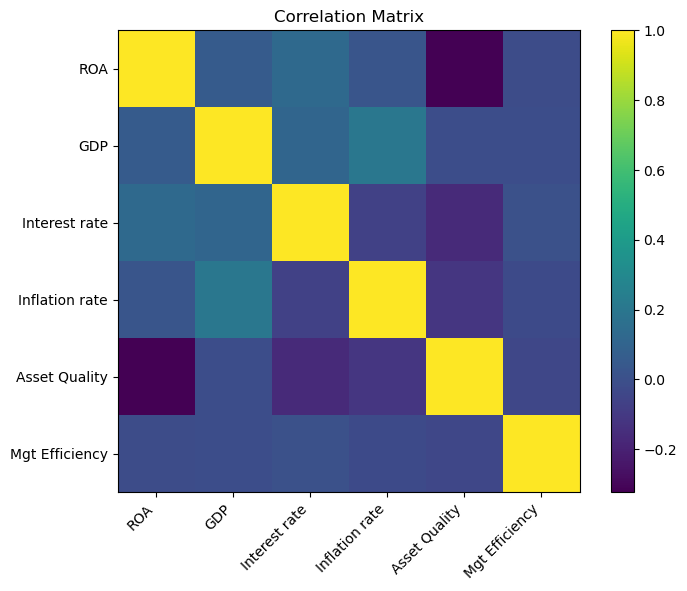

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(variables)), variables, rotation=45, ha='right')
plt.yticks(range(len(variables)), variables)
plt.title("Correlation Matrix")
plt.show()

In [42]:
from statsmodels. stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Independent variables only
X = df_reg[
    [
        "GDP",
        "Interest rate",
        "Inflation rate",
        "Asset Quality",
        "Mgt Efficiency"
    ]
]

# Create VIF table
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Variable,VIF
0,GDP,5.322141
1,Interest rate,13.578421
2,Inflation rate,11.988193
3,Asset Quality,2.521003
4,Mgt Efficiency,1.032664


In [43]:
import statsmodels.formula.api as smf

pooled_ols = smf.ols(
    'ROA ~ GDP + Q("Interest rate") + Q("Asset Quality") + Q("Mgt Efficiency")',
    data=df_reg
).fit()

print(pooled_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ROA   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     58.10
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.25e-46
Time:                        23:33:02   Log-Likelihood:                 3544.1
No. Observations:                1831   AIC:                            -7078.
Df Residuals:                    1826   BIC:                            -7051.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0040    

In [44]:
# Set panel structure: Bank and Time
df_fe = df_reg.set_index(['Bank', 'Time'])

In [45]:
from linearmodels. panel import PanelOLS

fixed_effects = PanelOLS.from_formula(
    'ROA ~ GDP + Q("Interest rate") + Q("Asset Quality") + Q("Mgt Efficiency") + EntityEffects',
    data=df_fe
)

fe_results = fixed_effects.fit()

print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.0317
Estimator:                   PanelOLS   R-squared (Between):              0.2566
No. Observations:                1831   R-squared (Within):               0.0317
Date:                Tue, May 05 2026   R-squared (Overall):              0.1516
Time:                        23:43:37   Log-likelihood                    4042.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      14.564
Entities:                          46   P-value                           0.0000
Avg Obs:                       39.804   Distribution:                  F(4,1781)
Min Obs:                       4.0000                                           
Max Obs:                       47.000   F-statistic (robust):             14.564
                            

In [46]:
from linearmodels. panel import RandomEffects

random_effects = RandomEffects.from_formula(
    'ROA ~ GDP + Q("Interest rate") + Q("Asset Quality") + Q("Mgt Efficiency")',
    data=df_fe
)

re_results = random_effects.fit()

print(re_results)

                        RandomEffects Estimation Summary                        
Dep. Variable:                    ROA   R-squared:                        0.0424
Estimator:              RandomEffects   R-squared (Between):              0.2820
No. Observations:                1831   R-squared (Within):               0.0313
Date:                Tue, May 05 2026   R-squared (Overall):              0.1660
Time:                        23:53:07   Log-likelihood                    4009.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      20.220
Entities:                          46   P-value                           0.0000
Avg Obs:                       39.804   Distribution:                  F(4,1827)
Min Obs:                       4.0000                                           
Max Obs:                       47.000   F-statistic (robust):             20.220
                            

In [47]:
from scipy.stats import shapiro

# Residuals from pooled OLS
residuals = pooled_ols.resid

shapiro_test = shapiro(residuals)
shapiro_test

ShapiroResult(statistic=np.float64(0.5410899261680436), pvalue=np.float64(2.561506678233533e-56))

In [48]:
from statsmodels. stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(pooled_ols.resid, pooled_ols.model.exog)

labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
dict(zip(labels, bp_test))

{'LM Statistic': np.float64(44.96277285776927),
 'LM p-value': np.float64(4.047451600023627e-09),
 'F Statistic': np.float64(11.492204920282495),
 'F p-value': np.float64(3.2446002511434815e-09)}

In [49]:
fe_robust = fixed_effects.fit(cov_type='robust')
print(fe_robust)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.0317
Estimator:                   PanelOLS   R-squared (Between):              0.2566
No. Observations:                1831   R-squared (Within):               0.0317
Date:                Wed, May 06 2026   R-squared (Overall):              0.1516
Time:                        00:03:30   Log-likelihood                    4042.2
Cov. Estimator:                Robust                                           
                                        F-statistic:                      14.564
Entities:                          46   P-value                           0.0000
Avg Obs:                       39.804   Distribution:                  F(4,1781)
Min Obs:                       4.0000                                           
Max Obs:                       47.000   F-statistic (robust):             17.798
                            

In [50]:
re_robust = random_effects.fit(cov_type='robust')
print(re_robust)

                        RandomEffects Estimation Summary                        
Dep. Variable:                    ROA   R-squared:                        0.0424
Estimator:              RandomEffects   R-squared (Between):              0.2820
No. Observations:                1831   R-squared (Within):               0.0313
Date:                Wed, May 06 2026   R-squared (Overall):              0.1660
Time:                        00:04:26   Log-likelihood                    4009.9
Cov. Estimator:                Robust                                           
                                        F-statistic:                      20.220
Entities:                          46   P-value                           0.0000
Avg Obs:                       39.804   Distribution:                  F(4,1827)
Min Obs:                       4.0000                                           
Max Obs:                       47.000   F-statistic (robust):             22.490
                            